In [11]:
# Install missing libraries
!pip install lime catboost optuna

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shap
import warnings
from lime import lime_tabular

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Suppress noisy warnings for the presentation
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.3 MB/s eta 0:00:00


In [5]:
# Download and locate the dataset
path = kagglehub.dataset_download("ethon0426/lending-club-20072020q1")
file_path = ""
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".gzip") or file.endswith(".csv"):
            file_path = os.path.join(root, file)
            break

# Columns identified for the Top 10 features
cols_to_use = [
    'loan_status', 'loan_amnt', 'last_pymnt_amnt', 'avg_cur_bal',
    'int_rate', 'installment', 'grade', 'annual_inc', 'dti',
    'revol_util', 'revol_bal', 'issue_d'
]

# Memory-efficient balanced sampling: 10k Fully Paid, 10k Charged Off
chunk_size = 50000
df_list = []
counts = {'Fully Paid': 0, 'Charged Off': 0}

for chunk in pd.read_csv(file_path, usecols=cols_to_use, chunksize=chunk_size, low_memory=False):
    filtered_chunk = chunk[chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])]
    for status in ['Fully Paid', 'Charged Off']:
        if counts[status] < 10000:
            needed = 10000 - counts[status]
            subset = filtered_chunk[filtered_chunk['loan_status'] == status].head(needed)
            df_list.append(subset)
            counts[status] += len(subset)

    if counts['Fully Paid'] >= 10000 and counts['Charged Off'] >= 10000:
        break

df_sample = pd.concat(df_list).reset_index(drop=True)
print(f"Balanced sample created: {df_sample['loan_status'].value_counts().to_dict()}")

100%|██████████| 482M/482M [00:03<00:00, 149MB/s]

Extracting files...


Balanced sample created: {'Fully Paid': 10000, 'Charged Off': 10000}


In [6]:
# Mapping categorical variables
df_sample['target'] = df_sample['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
df_sample['grade'] = df_sample['grade'].map({'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7})

# Cleaning percentage strings
for col in ['int_rate', 'revol_util']:
    if df_sample[col].dtype == 'object':
        df_sample[col] = df_sample[col].str.rstrip('%').astype(float)

features = [
    'loan_amnt', 'last_pymnt_amnt', 'avg_cur_bal', 'int_rate', 'installment',
    'grade', 'annual_inc', 'dti', 'revol_util', 'revol_bal'
]

X = df_sample[features].fillna(0)
y = df_sample['target']

# 70% Train, 20% Test, 10% Validation split
X_train_raw, X_rem_raw, y_train, y_rem = train_test_split(X, y, train_size=0.70, random_state=0, stratify=y)
X_test_raw, X_val_raw, y_test, y_val = train_test_split(X_rem_raw, y_rem, test_size=0.33, random_state=0, stratify=y_rem)

# Normalization
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
X_val = scaler.transform(X_val_raw)

print(f"Sets created - Train: {len(X_train)} | Test: {len(X_test)} | Val: {len(X_val)}")

Sets created - Train: 14000 | Test: 4020 | Val: 1980


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 7000, number of negative: 7000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001978 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2242
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

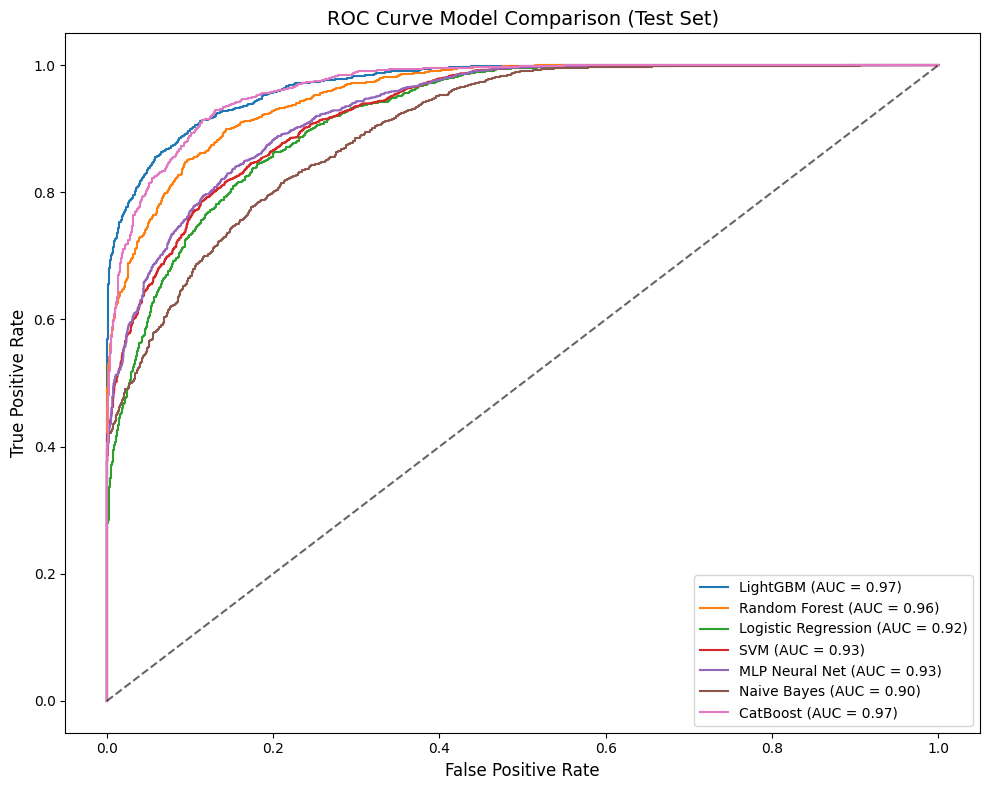


Model Performance Summary:


,Model,Test Accuracy,AUC
0,LightGBM,0.898,0.971
1,CatBoost,0.896,0.967
2,Random Forest,0.875,0.956
3,MLP Neural Net,0.843,0.933
4,SVM,0.834,0.930
5,Logistic Regression,0.830,0.921
6,Naive Bayes,0.708,0.902


In [7]:
models = {
    "LightGBM": LGBMClassifier(n_estimators=250, learning_rate=0.3, max_depth=3, reg_alpha=4, reg_lambda=5, min_data_in_leaf=20, random_state=0, importance_type='gain'),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_leaf=10, max_depth=20, random_state=0),
    "Logistic Regression": LogisticRegression(C=10, random_state=1),
    "SVM": SVC(C=10, kernel='rbf', probability=True, random_state=0),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(5,2), alpha=1e-5, max_iter=300, random_state=1),
    "Naive Bayes": GaussianNB(),
    "CatBoost": CatBoostClassifier(iterations=1000, depth=10, learning_rate=0.5, l2_leaf_reg=5, random_state=0, verbose=0)
}

results = []
plt.figure(figsize=(10, 8))

# Train, predict, and plot in one pass
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
    results.append({"Model": name, "Test Accuracy": acc, "AUC": auc_score})

# Format the ROC Curve visualization
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title("ROC Curve Model Comparison (Test Set)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# Display a clean summary dataframe
df_results = pd.DataFrame(results).sort_values(by="AUC", ascending=False).reset_index(drop=True)
print("\nModel Performance Summary:")
display(df_results.round(3))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
FINAL UNSEEN VALIDATION ACCURACY: 0.8874

Generating SHAP Global Feature Importance...


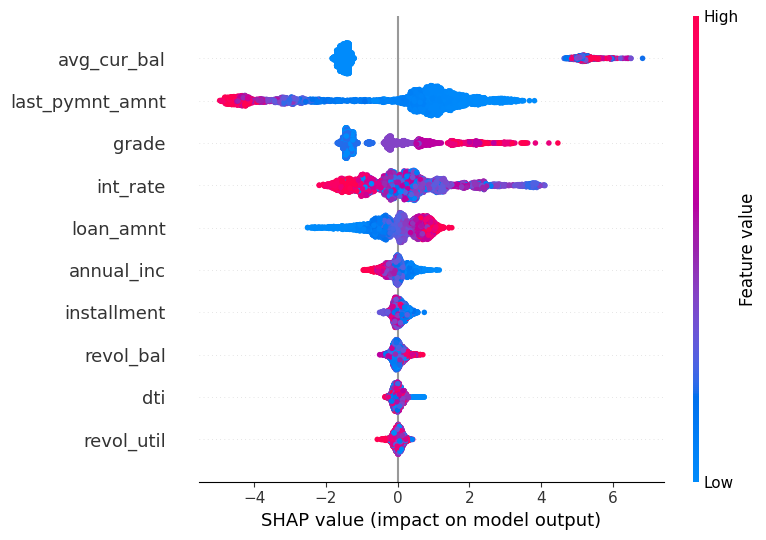

Generating LIME Local Explanation for a single borrower...
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


In [8]:
# Select the best performing model for final validation
best_model = models["LightGBM"]
final_pred = best_model.predict(X_val)
print(f"FINAL UNSEEN VALIDATION ACCURACY: {accuracy_score(y_val, final_pred):.4f}\n")

# 1. SHAP Global Explanation
print("Generating SHAP Global Feature Importance...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features)

# 2. LIME Local Explanation (Explaining the first Validation instance)
print("Generating LIME Local Explanation for a single borrower...")
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=features,
    class_names=['Fully Paid', 'Charged Off'],
    mode='classification'
)
exp = lime_explainer.explain_instance(X_val[0], best_model.predict_proba)
exp.show_in_notebook(show_table=True, show_all=False)

In [12]:
import xgboost as xgb
import optuna

def objective(trial):
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0)
    }

    # Train XGBoost with trial parameters
    gbm = xgb.XGBClassifier(**param)
    gbm.fit(X_train, y_train)
    preds = gbm.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

# Suppress Optuna logging for a clean presentation
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Starting Optuna hyperparameter tuning for XGBoost (50 trials)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Tuning Complete!")
print(f"Best AUC: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}\n")

# Add the best tuned XGBoost model to our dictionary for the final comparison
best_xgb = xgb.XGBClassifier(**study.best_params, eval_metric='auc')
best_xgb.fit(X_train, y_train)
models["Tuned XGBoost"] = best_xgb

Starting Optuna hyperparameter tuning for XGBoost (50 trials)...
Tuning Complete!
Best AUC: 0.9680
Best Parameters: {'n_estimators': 700, 'max_depth': 11, 'learning_rate': 0.046650885506683976, 'scale_pos_weight': 4.122491101490136, 'subsample': 0.9745460073560617}



In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

results_table = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_table.append({
        "Model": name,
        "AUC": roc_auc_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Format and display the clean dataframe
df_metrics = pd.DataFrame(results_table).sort_values(by="AUC", ascending=False).reset_index(drop=True)
print("--- Final Model Comparison (Test Set) ---")
display(df_metrics.round(3))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
--- Final Model Comparison (Test Set) ---


,Model,AUC,Accuracy,Precision,Recall,F1-Score
0,LightGBM,0.971,0.898,0.903,0.892,0.898
1,Tuned XGBoost,0.968,0.897,0.875,0.926,0.900
2,CatBoost,0.967,0.896,0.898,0.893,0.895
3,Random Forest,0.956,0.875,0.864,0.891,0.877
4,MLP Neural Net,0.933,0.843,0.845,0.839,0.842
5,SVM,0.930,0.834,0.814,0.865,0.839
6,Logistic Regression,0.921,0.830,0.824,0.839,0.831
7,Naive Bayes,0.902,0.708,0.988,0.422,0.591
